<a href="https://colab.research.google.com/github/vishnubyneni/MLA0202-MACHINE-LEARNING/blob/main/AgglomerativeClustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Step-1) Find the Customers who are spending Electromnics,cloting,croceries,furniture,sports

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data Understanding

In [5]:
df=pd.read_excel("/content/agglomerative_dataset.xlsx")

In [6]:
df

,Customer_ID,True_Cluster,Age,Gender,Region,Discount_Usage(%),Purchase_Frequency,Return_Rate(%),Annual_Revenue(₹),Customer_Rating
0,1,Sports,46,Female,South,39.92,75.39,50.59,25455.10,3.40
1,2,Electronics,39,Male,South,89.23,83.92,95.88,53482.34,3.72
2,3,Furniture,35,Female,South,59.99,47.94,77.71,22506.50,4.04
3,4,Groceries,31,Female,North,19.87,98.03,27.64,7063.96,3.36
4,5,Furniture,45,Female,South,69.22,58.59,72.77,34610.42,4.32
...,...,...,...,...,...,...,...,...,...,...
1995,1996,Groceries,59,Male,North,20.51,93.51,34.43,8837.11,2.73
1996,1997,Furniture,49,Male,East,67.28,32.17,76.38,23846.31,3.85
1997,1998,Groceries,30,Male,South,12.94,99.02,31.68,12199.16,2.74
1998,1999,Furniture,22,Male,South,51.93,48.84,72.73,55091.36,3.84


In [7]:
df.shape

(2000, 10)

* Customer Dataset There are 2000 rows and 10 Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Customer_ID         2000 non-null   int64  
 1   True_Cluster        2000 non-null   object 
 2   Age                 2000 non-null   int64  
 3   Gender              2000 non-null   object 
 4   Region              2000 non-null   object 
 5   Discount_Usage(%)   2000 non-null   float64
 6   Purchase_Frequency  2000 non-null   float64
 7   Return_Rate(%)      2000 non-null   float64
 8   Annual_Revenue(₹)   2000 non-null   float64
 9   Customer_Rating     2000 non-null   float64
dtypes: float64(5), int64(2), object(3)
memory usage: 156.4+ KB


* All Columns Have Correct data types
* NO need to change Data Types

In [9]:
df.describe()

,Customer_ID,Age,Discount_Usage(%),Purchase_Frequency,Return_Rate(%),Annual_Revenue(₹),Customer_Rating
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000
mean,1000.500000,43.445000,48.796180,70.272670,62.081835,29451.30378,3.881960
std,577.494589,15.057036,23.578837,20.875928,21.302488,18056.62214,0.490079
min,1.000000,18.000000,3.920000,17.550000,9.070000,1000.00000,2.180000
25%,500.750000,31.000000,29.947500,53.930000,47.870000,14587.46500,3.540000
50%,1000.500000,43.000000,44.255000,72.390000,63.025000,25472.89500,3.900000
75%,1500.250000,57.000000,66.857500,89.120000,79.557500,41404.76750,4.210000
max,2000.000000,69.000000,100.000000,100.000000,100.000000,96648.78000,5.000000


* Here total rows are 2000
* Standard Deviation is less than the mean in every column
* so we conclude that data is not spreaded very highly

In [10]:
df.isnull().sum()

,0
Customer_ID,0
True_Cluster,0
Age,0
Gender,0
Region,0
Discount_Usage(%),0
Purchase_Frequency,0
Return_Rate(%),0
Annual_Revenue(₹),0
Customer_Rating,0


* No null valus or Misiiing values
* no wrong data

In [12]:
df.duplicated().sum()

np.int64(0)

* No  Duplicte Values

# Data Cleaning And Data Pre-Processing

In [14]:
df.dropna(inplace=True)

In [15]:
df.fillna(df.mean(numeric_only=True),inplace=True)

In [16]:
df.drop_duplicates(inplace=True)

In [17]:
obj_cols = df.select_dtypes(include='object')
print(obj_cols)

     True_Cluster  Gender Region
0          Sports  Female  South
1     Electronics    Male  South
2       Furniture  Female  South
3       Groceries  Female  North
4       Furniture  Female  South
...           ...     ...    ...
1995    Groceries    Male  North
1996    Furniture    Male   East
1997    Groceries    Male  South
1998    Furniture    Male  South
1999    Groceries    Male   West

[2000 rows x 3 columns]


* in this datset we have object data type we need to encode to 0,1

In [ ]:
df[""]


In [ ]:
obj_cols = df.select_dtypes(include='object')
print(obj_cols)

     True_Cluster  Gender Region
0          Sports  Female  South
1     Electronics    Male  South
2       Furniture  Female  South
3       Groceries  Female  North
4       Furniture  Female  South
...           ...     ...    ...
1995    Groceries    Male  North
1996    Furniture    Male   East
1997    Groceries    Male  South
1998    Furniture    Male  South
1999    Groceries    Male   West

[2000 rows x 3 columns]


In [18]:
df["Gender"]=df["Gender"].map({"Male":0,"Female":1})

In [19]:
df['Region'] = pd.factorize(df['Region'])[0]

In [21]:
def remove_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    return df[(df[col] >= Q1 - 1.5*IQR) & (df[col] <= Q3 + 1.5*IQR)]

In [22]:
df

,Customer_ID,True_Cluster,Age,Gender,Region,Discount_Usage(%),Purchase_Frequency,Return_Rate(%),Annual_Revenue(₹),Customer_Rating
0,1,Sports,46,1,0,39.92,75.39,50.59,25455.10,3.40
1,2,Electronics,39,0,0,89.23,83.92,95.88,53482.34,3.72
2,3,Furniture,35,1,0,59.99,47.94,77.71,22506.50,4.04
3,4,Groceries,31,1,1,19.87,98.03,27.64,7063.96,3.36
4,5,Furniture,45,1,0,69.22,58.59,72.77,34610.42,4.32
...,...,...,...,...,...,...,...,...,...,...
1995,1996,Groceries,59,0,1,20.51,93.51,34.43,8837.11,2.73
1996,1997,Furniture,49,0,3,67.28,32.17,76.38,23846.31,3.85
1997,1998,Groceries,30,0,0,12.94,99.02,31.68,12199.16,2.74
1998,1999,Furniture,22,0,0,51.93,48.84,72.73,55091.36,3.84


In [27]:
features=["Discount_Usage(%)","Purchase_Frequency","Return_Rate(%)","Annual_Revenue(₹)","Customer_Rating"]

In [29]:
x=df[features]

# Feature Scaling

In [37]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)
print("Mean:", x_scaled.mean(axis=0).round(2))   # ~[0, 0, 0, 0, 0]
print("Std :", x_scaled.std(axis=0).round(2))    # ~[1, 1, 1, 1, 1]
x_scaled_df = pd.DataFrame(x_scaled, columns=features)
print(x_scaled_df.describe().round(2))

Mean: [ 0. -0.  0. -0.  0.]
Std : [1. 1. 1. 1. 1.]
       Discount_Usage(%)  Purchase_Frequency  Return_Rate(%)  \
count            2000.00             2000.00         2000.00   
mean                0.00               -0.00            0.00   
std                 1.00                1.00            1.00   
min                -1.90               -2.53           -2.49   
25%                -0.80               -0.78           -0.67   
50%                -0.19                0.10            0.04   
75%                 0.77                0.90            0.82   
max                 2.17                1.42            1.78   

       Annual_Revenue(₹)  Customer_Rating  
count            2000.00          2000.00  
mean               -0.00             0.00  
std                 1.00             1.00  
min                -1.58            -3.47  
25%                -0.82            -0.70  
50%                -0.22             0.04  
75%                 0.66             0.67  
max                 

# Dendigram-Optimal Clusters

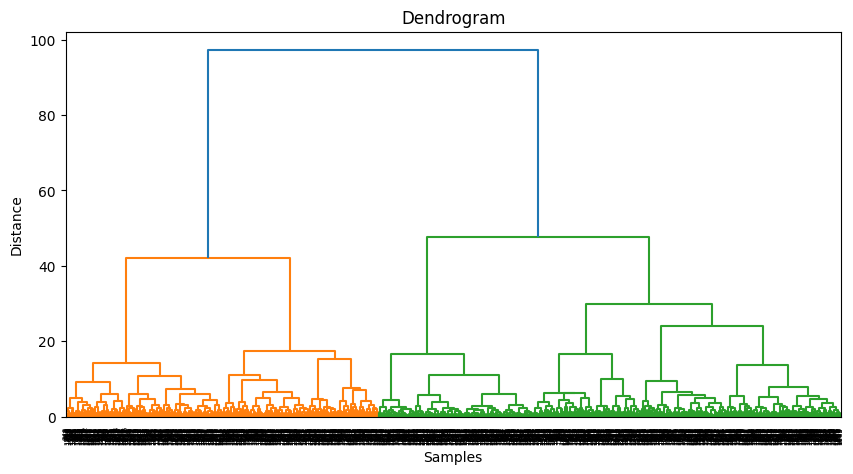

In [56]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

# Build linkage matrix
linked = linkage(x_scaled_df, method='ward')

# Plot dendrogram
plt.figure(figsize=(10, 5))
dendrogram(linked)

plt.title("Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")

plt.show()

# Model SELECTION

In [47]:
from sklearn.cluster import AgglomerativeClustering
model = AgglomerativeClustering(
    n_clusters=5,
    linkage='ward',
    metric='euclidean'
)


labels = model.fit_predict(x_scaled_df)

df['Cluster_Label'] = labels
print(df['Cluster_Label'].value_counts().sort_index())
cluster_summary = df.groupby('Cluster_Label')[features].mean().round(2)
print(cluster_summary)

Cluster_Label
0    513
1    401
2    400
3    407
4    279
Name: count, dtype: int64
               Discount_Usage(%)  Purchase_Frequency  Return_Rate(%)  \
Cluster_Label                                                          
0                          38.27               70.59           56.71   
1                          84.93               70.83           89.93   
2                          19.98               94.90           30.30   
3                          59.58               39.99           74.96   
4                          41.80               77.76           58.71   

               Annual_Revenue(₹)  Customer_Rating  
Cluster_Label                                      
0                       21846.37             3.56  
1                       51617.15             4.23  
2                        9993.58             3.51  
3                       40581.08             4.01  
4                       23236.59             4.31  


In [51]:
print(pd.crosstab(df['Cluster_Label'], df['True_Cluster']))


True_Cluster   Clothing  Electronics  Furniture  Groceries  Sports
Cluster_Label                                                     
0                   213            0          0          0     300
1                     0          399          2          0       0
2                     0            0          0        400       0
3                     0            0        397          0      10
4                   187            1          1          0      90


In [52]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# 1. Silhouette Score (-1 to 1, higher is better)
sil = silhouette_score(x_scaled_df, labels)
print(f"Silhouette Score : {sil:.4f}")

# 2. Davies-Bouldin Score (lower is better)
db = davies_bouldin_score(x_scaled_df, labels)
print(f"Davies-Bouldin   : {db:.4f}")

# 3. Calinski-Harabasz Score (higher is better)
ch = calinski_harabasz_score(x_scaled_df, labels)
print(f"Calinski-Harabasz: {ch:.2f}")

# True labels తో compare చేయడం (labels ఉంటే)
from sklearn.metrics import adjusted_rand_score
true_labels = df['True_Cluster'].factorize()[0]
ari = adjusted_rand_score(true_labels, labels)
print(f"Adjusted Rand Index: {ari:.4f}")

Silhouette Score : 0.3247
Davies-Bouldin   : 1.2378
Calinski-Harabasz: 1281.44
Adjusted Rand Index: 0.7552


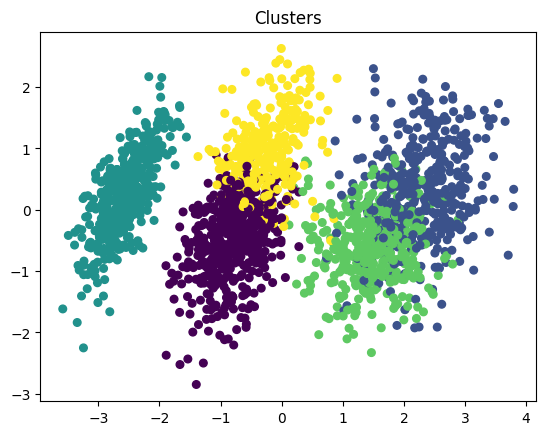

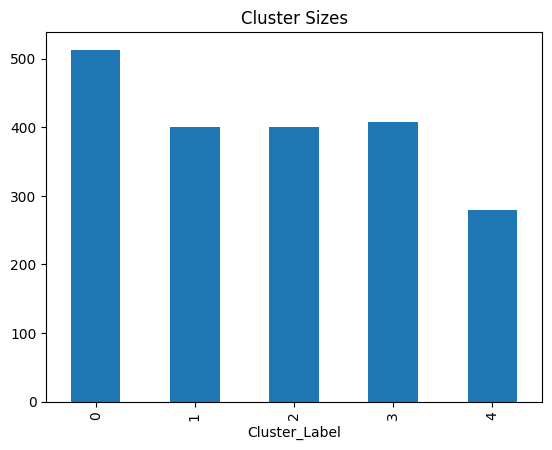

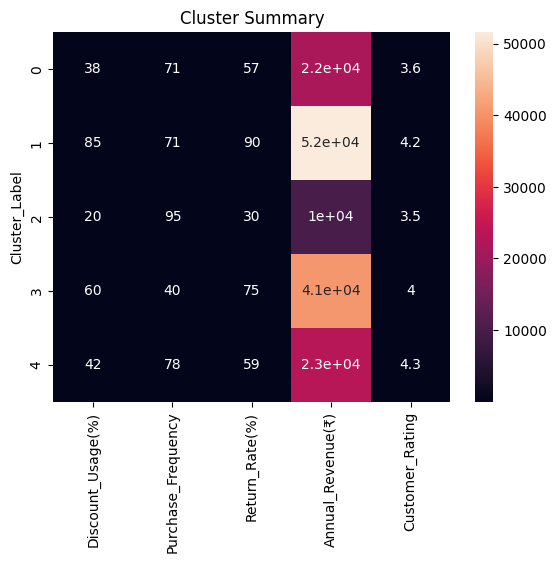

In [55]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
pca = PCA(n_components=2)
X_pca = pca.fit_transform(x_scaled_df)
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, s=30)
plt.title("Clusters")
plt.show()
df['Cluster_Label'].value_counts().sort_index().plot(kind='bar')
plt.title("Cluster Sizes")
plt.show()
sns.heatmap(cluster_summary, annot=True)
plt.title("Cluster Summary")
plt.show()